# Actuarial Pricing and Reserving Notebook
This professional actuarial notebook covers portfolio construction, exposure measurement, rate-setting, credibility, reserving, and risk governance.

## Purpose
This notebook is designed for senior actuarial practitioners, pricing actuaries, and reserving analysts. It provides a long-form workflow that connects underwriting, pricing, claims development, and capital allocation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

## Portfolio assumptions and actuarial framework
Define the scope, lines of business, granularity, and the key actuarial questions that this work answers.

In [3]:
portfolio_description = {
    "line_of_business": "personal auto",
    "pricing_horizon": "annual policy period",
    "reserve_horizon": "3-year claims development",
    "pricing_objective": "rate adequacy and risk-based pricing",
    "reserving_objective": "liability estimation for unpaid claims and tail exposures",
    "governance": "monitor model drift, ensure transparency, and align pricing with capital strategy",
}

pd.Series(portfolio_description)

line_of_business                                           personal auto
pricing_horizon                                     annual policy period
reserve_horizon                                3-year claims development
pricing_objective                   rate adequacy and risk-based pricing
reserving_objective    liability estimation for unpaid claims and tai...
governance             monitor model drift, ensure transparency, and ...
dtype: str

## Synthetic actuarial dataset
Generate an actuarial portfolio dataset with exposure, policy, and claim characteristics that support pricing and reserving analysis.

In [4]:
def generate_actuarial_portfolio(n_policies=1800, random_state=42):
    rng = np.random.default_rng(random_state)

    exposure = rng.uniform(0.2, 1.0, n_policies)
    age = rng.integers(18, 80, size=n_policies)
    vehicle_age = rng.integers(0, 20, size=n_policies)
    territory = rng.choice(["Urban", "Suburban", "Rural"], size=n_policies, p=[0.52, 0.33, 0.15])
    gender = rng.choice(["Male", "Female"], size=n_policies, p=[0.54, 0.46])
    telematics = rng.choice(["Yes", "No"], size=n_policies, p=[0.24, 0.76])
    past_claims = rng.poisson(0.4, size=n_policies)
    premium = 400 + age * 5 + vehicle_age * 12 + exposure * 200
    territory_adj = np.select([territory=="Urban", territory=="Suburban"], [180, -80], default=-160)
    gender_adj = np.where(gender=="Male", 40, -40)
    telematics_disc = np.where(telematics=="Yes", -150, 0)
    claim_frequency = rng.poisson(0.25 + 0.002 * age + 0.15 * (territory=="Urban"))
    claim_severity = rng.lognormal(mean=8.5, sigma=0.9, size=n_policies)
    incurred_claims = np.round(claim_frequency * claim_severity * exposure, 2)
    loss_ratio = np.round(incurred_claims / premium, 3)

    df = pd.DataFrame({
        "exposure": exposure,
        "age": age,
        "vehicle_age": vehicle_age,
        "territory": territory,
        "gender": gender,
        "telematics": telematics,
        "past_claims": past_claims,
        "premium": np.round(premium + territory_adj + gender_adj + telematics_disc, 2),
        "incurred_claims": incurred_claims,
        "loss_ratio": loss_ratio,
    })
    df["risk_segment"] = pd.cut(df["age"], bins=[17, 30, 45, 60, 100], labels=["Young", "Early Career", "Mid Career", "Senior"], ordered=True)
    return df

portfolio_df = generate_actuarial_portfolio()
portfolio_df.head()

,exposure,age,vehicle_age,territory,gender,telematics,past_claims,premium,incurred_claims,loss_ratio,risk_segment
0,0.819165,45,17,Urban,Female,No,1,1132.83,0.00,0.000,Early Career
1,0.551103,55,13,Urban,Male,No,0,1161.22,0.00,0.000,Mid Career
2,0.886878,27,13,Urban,Male,Yes,0,938.38,0.00,0.000,Young
3,0.757894,56,10,Urban,Male,No,0,1171.58,25610.34,26.914,Mid Career
4,0.275342,75,0,Rural,Female,No,1,630.07,0.00,0.000,Senior


## Portfolio diagnostics
Analyze the exposure profile, pricing adequacy, and loss ratio distribution before modeling.

Portfolio shape: (1800, 11)


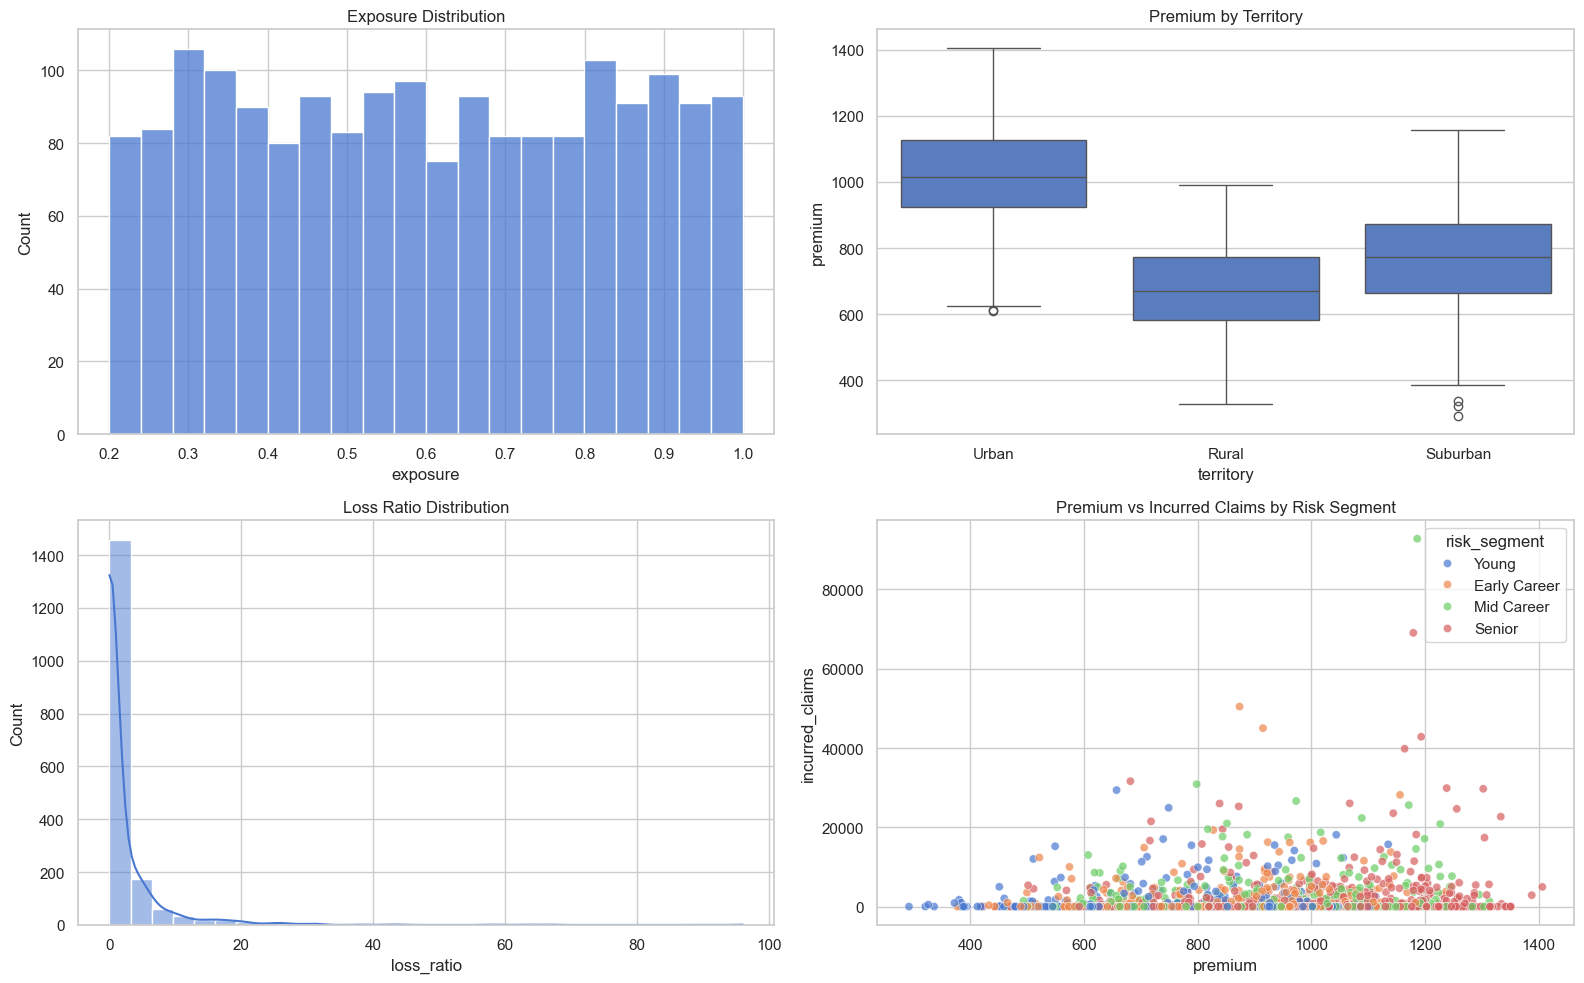

In [5]:
print(f"Portfolio shape: {portfolio_df.shape}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(portfolio_df["exposure"], bins=20, ax=axes[0, 0])
axes[0, 0].set_title("Exposure Distribution")

sns.boxplot(x="territory", y="premium", data=portfolio_df, ax=axes[0, 1])
axes[0, 1].set_title("Premium by Territory")

sns.histplot(portfolio_df["loss_ratio"], bins=30, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("Loss Ratio Distribution")

sns.scatterplot(x="premium", y="incurred_claims", hue="risk_segment", data=portfolio_df, ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title("Premium vs Incurred Claims by Risk Segment")

plt.tight_layout()
plt.show()

## Frequency and severity analysis
Separate claim incident frequency from claim severity for more stable pricing and reserving.

In [6]:
portfolio_df["has_claim"] = (portfolio_df["incurred_claims"] > 0).astype(int)
portfolio_df["claim_severity"] = np.where(portfolio_df["has_claim"] == 1, portfolio_df["incurred_claims"], np.nan)

frequency_table = portfolio_df.groupby(["territory", "telematics"]) ["has_claim"].mean().reset_index()
severity_table = portfolio_df.loc[portfolio_df["has_claim"] == 1].groupby(["territory", "telematics"])["claim_severity"].mean().reset_index()

frequency_table.head(), severity_table.head()

(  territory telematics  has_claim
 0     Rural         No   0.293478
 1     Rural        Yes   0.365079
 2  Suburban         No   0.263403
 3  Suburban        Yes   0.261905
 4     Urban         No   0.372549,
   territory telematics  claim_severity
 0     Rural         No     4713.585185
 1     Rural        Yes     5969.406087
 2  Suburban         No     4967.265398
 3  Suburban        Yes     4978.209697
 4     Urban         No     5943.464035)

## Credibility and credibility-weighted rate projections
Calculate basic Bühlmann credibility factors for limited exposure cells.

In [7]:
# Credibility exercise for risk cell frequency
cell_stats = (
    portfolio_df.groupby(["territory", "telematics"])
    .agg(
        exposure_sum=("exposure", "sum"),
        claims=("has_claim", "sum"),
        frequency=("has_claim", "mean"),
    )
    .reset_index()
)

# Estimate variance components
overall_frequency = portfolio_df["has_claim"].mean()
within_var = np.average(cell_stats["frequency"] * (1 - cell_stats["frequency"]))
between_var = np.var(cell_stats["frequency"], ddof=1)
credibility_constant = within_var / between_var if between_var > 0 else 0

cell_stats["credibility"] = cell_stats.apply(
    lambda row: row["exposure_sum"] / (row["exposure_sum"] + credibility_constant), axis=1
)
cell_stats["credibility_weighted_frequency"] = (
    cell_stats["credibility"] * cell_stats["frequency"] +
    (1 - cell_stats["credibility"]) * overall_frequency
)

cell_stats.head()

,territory,telematics,exposure_sum,claims,frequency,credibility,credibility_weighted_frequency
0,Rural,No,107.975703,54,0.293478,0.697973,0.306858
1,Rural,Yes,36.144958,23,0.365079,0.436174,0.349686
2,Suburban,No,263.341581,113,0.263403,0.849311,0.274611
3,Suburban,Yes,76.296563,33,0.261905,0.620197,0.290722
4,Urban,No,465.014372,285,0.372549,0.908697,0.369374


## Generalized linear modeling for pricing
Fit a GLM-style pricing model using transformed exposure-adjusted data.

In [8]:
pricing_df = portfolio_df.copy()
pricing_df["log_exposure"] = np.log(pricing_df["exposure"])
pricing_df["log_premium"] = np.log(pricing_df["premium"])

feature_cols = ["age", "vehicle_age", "past_claims"]
categorical_cols = ["territory", "gender", "telematics", "risk_segment"]

X = pricing_df[feature_cols + categorical_cols]
y = pricing_df["incurred_claims"]

full_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

pricing_model = Pipeline(
    steps=[
        ("preprocessor", full_preprocessor),
        ("linear", RidgeCV(alphas=np.logspace(-3, 3, 13), scoring="neg_mean_squared_error")),
    ]
)

pricing_model.fit(X, y)
predicted_losses = pricing_model.predict(X)

pricing_metrics = {
    "MAE": mean_absolute_error(y, predicted_losses),
    "RMSE": np.sqrt(mean_squared_error(y, predicted_losses)),
    "R2": r2_score(y, predicted_losses),
}

pricing_metrics

{'MAE': 2630.2905528091824,
 'RMSE': np.float64(5167.517872414719),
 'R2': 0.013413737887112531}

## Diagnostics and residual analysis
Senior actuaries validate model fit and identify cells with systematic over- or under-prediction.

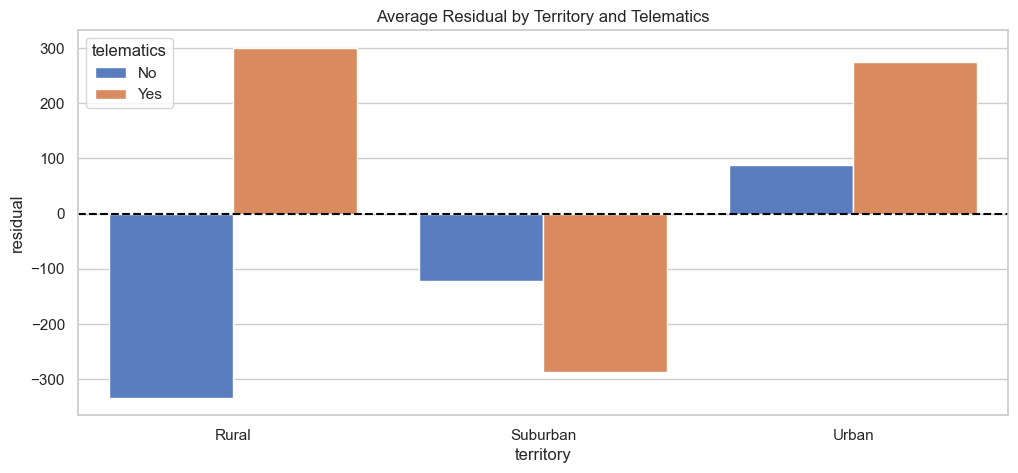

In [9]:
pricing_df["predicted_losses"] = predicted_losses
pricing_df["residual"] = pricing_df["incurred_claims"] - pricing_df["predicted_losses"]

cell_residual = pricing_df.groupby(["territory", "telematics"])["residual"].mean().reset_index()
cell_residual

plt.figure(figsize=(12, 5))
sns.barplot(x="territory", y="residual", hue="telematics", data=cell_residual)
plt.title("Average Residual by Territory and Telematics")
plt.axhline(0, color="black", linestyle="--")
plt.show()

## Claims development and reserving table
Create a synthetic claims development triangle and estimate unpaid liabilities using the chain-ladder method.

In [10]:
claim_triangle = pd.DataFrame(
    {
        "origin_year": [2018, 2019, 2020, 2021, 2022],
        1: [1200.0, 1350.0, 1500.0, 1250.0, 1400.0],
        2: [1750.0, 1940.0, 2160.0, 1800.0, np.nan],
        3: [2050.0, 2265.0, 2520.0, np.nan, np.nan],
        4: [2210.0, 2445.0, np.nan, np.nan, np.nan],
        5: [2325.0, np.nan, np.nan, np.nan, np.nan],
    }
).set_index("origin_year")
claim_triangle


,1,2,3,4,5
origin_year,,,,,
2018,1200.0,1750.0,2050.0,2210.0,2325.0
2019,1350.0,1940.0,2265.0,2445.0,NaN
2020,1500.0,2160.0,2520.0,NaN,NaN
2021,1250.0,1800.0,NaN,NaN,NaN
2022,1400.0,NaN,NaN,NaN,NaN


## Chain-ladder reserving
Estimate development factors and calculate ultimate claims and reserve requirements.

In [11]:
triangle = claim_triangle.copy()

factors = []
for i in range(1, triangle.shape[1]):
    prev_col = triangle.columns[i - 1]
    curr_col = triangle.columns[i]
    mask = triangle[[prev_col, curr_col]].notna().all(axis=1)
    prev_sum = triangle.loc[mask, prev_col].sum()
    curr_sum = triangle.loc[mask, curr_col].sum()
    factors.append((curr_sum / prev_sum).round(4) if prev_sum > 0 else 1.0)

factor_table = pd.DataFrame(
    {
        "development_step": [f"{i}->{i+1}" for i in range(1, len(factors) + 1)],
        "age_to_age_factor": factors,
    }
)
factor_table

cdf = np.cumprod(factors[::-1])[::-1]
ultimate = triangle.copy()

for origin in triangle.index:
    row = triangle.loc[origin]
    observed_cols = row.dropna().index
    last_col = observed_cols.max()
    last_pos = triangle.columns.get_loc(last_col)
    last_value = row[last_col]

    if last_pos < len(triangle.columns) - 1:
        projected = last_value
        for f in factors[last_pos:]:
            projected *= f
        ultimate.loc[origin, triangle.columns[last_pos + 1 :]] = [np.nan] * (len(triangle.columns) - last_pos - 1)
    else:
        projected = last_value

    ultimate.loc[origin, "ultimate_claims"] = projected
    ultimate.loc[origin, "latest_observed"] = last_value
    ultimate.loc[origin, "reserve_estimate"] = projected - last_value

ultimate


,1,2,3,4,5,ultimate_claims,latest_observed,reserve_estimate
origin_year,,,,,,,,
2018,1200.0,1750.0,2050.0,2210.0,2325.0,2325.000000,2325.0,0.000000
2019,1350.0,1940.0,2265.0,2445.0,NaN,2572.140000,2445.0,127.140000
2020,1500.0,2160.0,2520.0,NaN,NaN,2859.941952,2520.0,339.941952
2021,1250.0,1800.0,NaN,NaN,NaN,2386.825841,1800.0,586.825841
2022,1400.0,NaN,NaN,NaN,NaN,2679.556770,1400.0,1279.556770


## Loss reserving sensitivity and runoff analysis
Evaluate how the reserve estimate changes under more conservative development factors.

In [12]:
conservative_factors = [f * 1.05 for f in factors]
ultimate_conservative = triangle.copy()

for origin in triangle.index:
    row = triangle.loc[origin]
    observed_cols = row.dropna().index
    last_col = observed_cols.max()
    last_pos = triangle.columns.get_loc(last_col)
    last_value = row[last_col]

    if last_pos < len(triangle.columns) - 1:
        projected = last_value
        for f in conservative_factors[last_pos:]:
            projected *= f
    else:
        projected = last_value

    ultimate_conservative.loc[origin, "ultimate_claims"] = projected
    ultimate_conservative.loc[origin, "latest_observed"] = last_value
    ultimate_conservative.loc[origin, "reserve_estimate"] = projected - last_value

reserve_comparison = pd.DataFrame(
    {
        "base_reserve": ultimate["reserve_estimate"],
        "conservative_reserve": ultimate_conservative["reserve_estimate"],
    }
)
reserve_comparison["increase"] = reserve_comparison["conservative_reserve"] - reserve_comparison["base_reserve"]
reserve_comparison


,base_reserve,conservative_reserve,increase
origin_year,,,
2018,0.000000,0.000000,0.000000
2019,127.140000,255.747000,128.607000
2020,339.941952,633.086002,293.144050
2021,586.825841,963.049264,376.223423
2022,1279.556770,1857.018001,577.461231


## Model governance and actuarial sign-off
Summarize the actuarial governance framework for pricing and reserving, including documentation, review, and periodic validation.

In [13]:
key_governance_steps = [
    "Document data sources, assumptions, and exclusions",
    "Validate rating variables and exposure measures",
    "Benchmark model against experience and prior rate levels",
    "Conduct residual and credibility analysis by segment",
    "Review reserve estimates with actuarial committee and finance",
    "Monitor drift in key exposures, loss ratios, and claim development",
]

pd.Series(key_governance_steps, name="actuarial_governance_steps")

0    Document data sources, assumptions, and exclus...
1      Validate rating variables and exposure measures
2    Benchmark model against experience and prior r...
3    Conduct residual and credibility analysis by s...
4    Review reserve estimates with actuarial commit...
5    Monitor drift in key exposures, loss ratios, a...
Name: actuarial_governance_steps, dtype: str

## Senior actuarial summary
This notebook demonstrates a complete actuarial workflow from pricing to reserving, with a strong focus on portfolio segmentation, credibility, and risk governance.

### Key deliverables
- Actuarial portfolio diagnostics and pricing adequacy.
- Frequency/severity decomposition and credibility-weighted frequency.
- GLM-style pricing and residual cell diagnostics.
- Claims development chain-ladder reserving and sensitivity analysis.
- Governance checklist for actuarial model management.